In [1]:
import ROOT as r
import fedrarootlogon 
from matplotlib import pyplot as plt
import matplotlib
import awkward as ak
import uproot
import numpy as np
import sys
sys.path.insert(0, "/home/baronunix/Scripts/")
from Clustering_Cosmici_Frammenti import *
import time


def g_func(x, p1, p2, p3):
    return p1* np.exp(- (x - p2)**2 / (2*p3**2) )
brick_id = "GSI2"
r.gStyle.SetOptStat("em")
PLOTS=0

Welcome to JupyROOT 6.26/06
Load FEDRA libs


In [2]:
%jsroot on 
k0_min = 1
outname = "output_b222_NEW_k0_min"+str(k0_min)+".root"

In [3]:
track_name = "b000222.2.0.0.trk.root"
file_name = "b22_vol.root"
Calcolo_Variabili_Volume_New(file_name, track_name)

1

## Taglio k0

In [4]:

file = r.TFile(file_name, "READ")

tracks_V = file.Get("tracks_n")

file2 = r.TFile("b22_cuts.root", "RECREATE")

t_tracks_V = tracks_V.CopyTree("k0>=" + str(k0_min) + " && VR0_av < 25000")
t_tracks_V.Write("tracks_k0_k1")
file2.Close()
file.Close()


In [5]:
file2 = r.TFile("b22_cuts.root", "READ")
tracks_2 = file2.Get("tracks_k0_k1")

In [6]:
a0, b0 = 3350, 0.7
a1, b1 = 4000, 0.7
a2, b2 = 3350, 0.7

multiplier = 1.
w, h = int(800*multiplier), int(600*multiplier)

c = r.TCanvas("c", "c", w, h)
c.SetLeftMargin(-10.)
c.SetWindowSize(w,h)
tracks_2.Draw("VR0_av:tan>>vr0_tan(100, 0,1, 100, 0, 20000)", "k1<2 && k2<2 && k3<2", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("<VR0> vs tan(#theta) [k_{1}<2 & k_{2}<2 & k_{3}<2]; tan(#theta); <VR0>")
vr0_tan.Draw("COLZ")
cut_curve = r.TF1("cut", str(a0)+"*(1 + exp("+str(b0)+ " *x*x))", 0, 1)
cut_curve.SetLineColor(2)
cut_curve.SetLineWidth(3)
#cut_curve.Draw("SAME")

cut_curve2 = r.TF1("cut2", str(a1)+"*(1 + exp("+str(b1)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
#cut_curve2.Draw("SAME")

cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve3.SetLineColor(2)
cut_curve3.SetLineWidth(3)
cut_curve3.Draw("SAME")

t1 = r.TText(0.1, 1800, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

r.gPad.Update()
st = vr0_tan.FindObject("stats")
st.SetX1NDC(0.70)
st.SetX2NDC(0.90)
st.SetY1NDC(0.70)
st.SetY2NDC(0.90)

c.SaveAs("GSI2_VR0tan.png")
c.Draw()

Info in <TCanvas::Print>: png file GSI2_VR0tan.png has been created


In [7]:
if (PLOTS==1):

    multiplier = 1.7
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR0_av:tan>>vr0_tan(100, 0,1, 100, 0, 25000)", "k1<2 && k2<2 && k3<2", "COLZ")

    vr0_tan = r.gDirectory.Get("vr0_tan")
    #vr0_tan.SetTitle("<VR0> vs tan(#theta) [k_{1}<2 & k_{2}<2 & k_{3}<2]; tan(#theta); <VR0>")
    vr0_tan.SetTitle("; tan(#theta); <VR0>")
    vr0_tan.GetXaxis().SetTitleSize(0.045)
    vr0_tan.GetYaxis().SetTitleSize(0.045)
    vr0_tan.Draw("COLZ")
    cut_curve = r.TF1("cut", str(a0)+"*(1 + exp("+str(b0)+ " *x*x))", 0, 1)
    cut_curve.SetLineColor(2)
    cut_curve.SetLineWidth(3)
    #cut_curve.Draw("SAME")

    cut_curve2 = r.TF1("cut2", str(a1)+"*(1 + exp("+str(b1)+ " *x*x))", 0, 1)
    cut_curve2.SetLineColor(2)
    cut_curve2.SetLineWidth(3)
    #cut_curve2.Draw("SAME")

    cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
    cut_curve3.SetLineColor(2)
    cut_curve3.SetLineWidth(6)
    cut_curve3.Draw("SAME")

    t1 = r.TText(0.1, 1800, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    r.gPad.Update()
    st = vr0_tan.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    
    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.11, 0.8,0.17,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI2_VR0tan.png")
    c.Draw()

## VR1 vs VR0

In [8]:
k = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>z1he(80, 5000,25000, 80, 0, 20000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >=2", "COLZ")

h = r.gDirectory.Get("z1he")
h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2]; <VR0>; <VR1>")
h.GetXaxis().SetRangeUser(6000,20500)
h.GetYaxis().SetRangeUser(0, 15500)
h.Draw("COLZ")

c1 = 5150
c2 = 5800
c0 = 5625
cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(4)
cut_curve2.Draw("SAME")

t1 = r.TText(15000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

k.Draw()

In [9]:
k = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>z1he(80, 5000,25000, 80, 0, 20000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))", "COLZ")

h = r.gDirectory.Get("z1he")
h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2]; <VR0>; <VR1>")
h.GetXaxis().SetRangeUser(6000,20500)
h.GetYaxis().SetRangeUser(0, 15500)
h.Draw("COLZ")

c1 = 5150
c2 = 5800
c0 = 5625
cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(4)
cut_curve2.Draw("SAME")

t1 = r.TText(15000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

k.Draw()

In [10]:
if (PLOTS==1):

    multiplier = 1.7
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0(80, 5000,25000, 80, 0, 20000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >= 2", "COLZ")

    h = r.gDirectory.Get("vr1_vr0")
    #h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2]; <VR0>; <VR1>")
    h.SetTitle(";<VR0>; <VR1>")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetYaxis().SetTitleSize(0.045)
    h.GetXaxis().SetRangeUser(6000,22500)
    h.GetYaxis().SetRangeUser(0, 15500)
    h.Draw("COLZ")

    c1 = 4750
    c2 = 5000
    #c0 = (c1+c2)/2
    c0 = 5500
    cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
    cut_curve2.SetLineColor(2)
    cut_curve2.SetLineWidth(6)
    cut_curve2.Draw("SAME")

    t1 = r.TText(15000, 5000, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    t1 = r.TText(0.1, 1800, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")

    r.gPad.Update()
    st = h.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    
    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.11, 0.8,0.17,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI2_VR1VR0.png")
    c.Draw()

In [11]:
if (PLOTS==1):

    multiplier = 1.7
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR2_av:VR1_av>>vr2_vr1(80, 0, 20000, 80, 0, 20000)", "k1 >= 1 && k2>=1", "COLZ")

    h = r.gDirectory.Get("vr2_vr1")
    #h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2]; <VR0>; <VR1>")
    h.SetTitle(";<VR1>; <VR2>")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetYaxis().SetTitleSize(0.045)
    #h.GetXaxis().SetRangeUser(6000,22500)
    #h.GetYaxis().SetRangeUser(0, 15500)
    h.Draw("COLZ")

    r.gPad.Update()
    st = h.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    
    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.11, 0.8,0.17,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI2_VR2VR1.png")
    c.Draw()

In [12]:
if (PLOTS==1):

    multiplier = 1.7
    w, h = int(800*multiplier), int(600*multiplier)

    c = r.TCanvas("c", "c", w, h)
    c.SetLeftMargin(0.13)
    c.SetBottomMargin(100)
    c.SetWindowSize(w,h)
    tracks_2.Draw("VR3_av:VR2_av>>vr3_vr2(80, 0, 20000, 80, 0, 20000)", "k3 >= 1 && k2>=1", "COLZ")

    h = r.gDirectory.Get("vr3_vr2")
    #h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2]; <VR0>; <VR1>")
    h.SetTitle(";<VR2>; <VR3>")
    h.GetXaxis().SetTitleSize(0.045)
    h.GetYaxis().SetTitleSize(0.045)
    #h.GetXaxis().SetRangeUser(6000,22500)
    #h.GetYaxis().SetRangeUser(0, 15500)
    h.Draw("COLZ")

    r.gPad.Update()
    st = h.FindObject("stats")
    st.SetX1NDC(0.70)
    st.SetX2NDC(0.90)
    st.SetY1NDC(0.70)
    st.SetY2NDC(0.90)

    
    newpad = r.TPad("newpad", "pd", 0, 0, 1, 1)
    newpad.SetFillStyle(4000)
    #newpad.Draw("SAME")
    newpad.cd()
    title = r.TPaveLabel(0.74,0.11, 0.8,0.17,brick_id)
    title.SetFillColor(0)
    title.SetTextFont(0)
    title.Draw("SAME")

    c.SaveAs("GSI2_VR3VR2.png")
    c.Draw()

## Test

In [13]:
k = r.TCanvas()
#VR0_av < " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))
tracks_2.Draw("k0", "4*k0/npl>=0.55", "COLZ")
k.Draw()
tracks_2.GetEntries()

64555

In [14]:
c = r.TCanvas()
tracks_2.Draw("VR0_av:tan>>vr0_tan(80, 0,1, 80, 0, 21000)", "k1<2 && k2<2 && k3<2", "COLZ")

vr0_tan = r.gDirectory.Get("vr0_tan")
vr0_tan.SetTitle("<VR0> vs tan(#theta) [k_{1}<2 & k_{2}<2 & k_{3}<2]; tan(#theta); <VR0>")
vr0_tan.Draw("COLZ")
cut_curve = r.TF1("cut", str(a0)+"*(1 + exp("+str(b0)+ " *x*x))", 0, 1)
cut_curve.SetLineColor(2)
cut_curve.SetLineWidth(3)
#cut_curve.Draw("SAME")

cut_curve2 = r.TF1("cut2", str(a1)+"*(1 + exp("+str(b1)+ " *x*x))", 0, 1)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(3)
#cut_curve2.Draw("SAME")

cut_curve3 = r.TF1("cut_med", str(a2)+"*(1 + exp("+str(b2)+ " *x*x))", 0, 1)
cut_curve3.SetLineColor(2)
cut_curve3.SetLineWidth(3)
cut_curve3.Draw("SAME")

t1 = r.TText(0.2, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.SetLogz()
c.Draw()

### Fine Test

In [15]:
k = r.TCanvas()
tracks_2.Draw("VR1_av:VR0_av>>vr1_vr0(80, 5000,25000, 80, 0, 25000)", "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) && k1 >= 2 && k2<2 && k3<2", "COLZ")

h = r.gDirectory.Get("vr1_vr0")
h.SetTitle("<VR1> vs <VR0> [Fragments, k_{1}>=2, k_{2}<2, k_{3}<2]; <VR0>; <VR1>")
h.GetXaxis().SetRangeUser(6000,20500)
h.GetYaxis().SetRangeUser(0, 15500)
h.Draw("COLZ")

cut_curve2 = r.TF1("cut2", str(c0), 4000, 26000)
cut_curve2.SetLineColor(2)
cut_curve2.SetLineWidth(4)
cut_curve2.Draw("SAME")

t1 = r.TText(15000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

k.Draw()

In [16]:
file_clust = r.TFile("Cluster_GSI2_cuts.root", "RECREATE")

cluster_v1 = tracks_2.CopyTree("VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan)) ")
cluster_v2 = tracks_2.CopyTree("k2 >=2 || k1 >=2 || k3 >=2")
cluster_v2.Write("cluster_v1")

9953

## VP123

In [17]:
r.Math.MinimizerOptions.SetDefaultMinimizer("Genetic")
r.Math.MinimizerOptions.SetDefaultTolerance(1e-10)

In [18]:
file_pca = r.TFile("PCA_123.root", "RECREATE")

campione_pca = cluster_v2.CopyTree("k1 >=1 && k2>=2 && k3>=1 || k1>=1 && k2>=1 && k3>=2")
campione_pca.Write("pca")

file_pca.Close()

In [19]:
file_clust.Close()

In [20]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_123.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [21]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI2/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [22]:
r.gSystem.Load("pca_C.so")
vr123s, vr123b = [], []
for track in info_pca:
    vr2, vr3, vr0 = track.VR1_av, track.VR2_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123, vr123b = [], []
for i in vr123s:
    vr123.append(i[0])
    vr123b.append(i[1])
    
file_pca.Close()

In [23]:
file_pca_2 = r.TFile("PCA2.root", "RECREATE")

pca_1 = r.TNtuple("pca_1", "", "VR123:VR123b")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i], vr123b[i])

In [24]:
kn = r.TCanvas()
pca_1.Draw("VR123>>123(70, -4., 7.)")

hi = r.gDirectory.Get("123")
hi.SetTitle("VP_{123} [k_{1}, k_{3}>=1 & k_{2}>=2 or k_{1}, k_{2}>=1 & k_{3}>=2]; VP_{123}; Entries")
hi.Draw("PE")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
legend.AddEntry("Cut", "Cut: k1 >=1 && k2>=2 && k3>=1 || k1>=1 && k2>=1 && k3>=2", "")
#legend.Draw("SAME")

t1 = r.TText(2, 200, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

kn.Draw()

In [25]:
pca_1.Write("pca")

431

### Fit Scelto

In [35]:
pca_1.Draw("VR123>>v123s(80, -4., 7.)", "", "COLZ")

r.gStyle.SetOptStat(0)
histos = r.gDirectory.Get("v123s")
histos.SetTitle("VP_{123} [GSI2]; VP_{123}; Entries")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(300, -1.5, .5, 150, 1., 0.5, 30, 3., 0.5)

#ampiezze
fit_func.SetParLimits(0, 80, 300)
fit_func.SetParLimits(3, 20, 200)
fit_func.SetParLimits(6, 10, 70)

#punto medio
fit_func.SetParLimits(1, -1.4, -1.)
fit_func.SetParLimits(4, -0.5, 2.)
fit_func.SetParLimits(7, 2.5, 3.5)

#deviazione_st
fit_func.SetParLimits(2, 0., 1.)
fit_func.SetParLimits(5, 0., 1.)
fit_func.SetParLimits(8, 0., 1.)

tr = -1.8
histos.Fit("fit_func", "S", "", tr, 7)
histos.GetFunction("fit_func").SetLineColor(2)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", tr, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(95)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -4., tr)
comp4.SetParameters(params[0], params[1], params[2])
comp4.SetLineColor(4)
comp4.SetLineStyle(2)
comp4.Draw("SAME")

legend = r.TLegend(0.6,0.55,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Overall Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()), "")
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "")
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 4)), "")
legend.Draw("SAME")

line = r.TLine(tr, 0, tr, 563)
line.SetLineColor(12)
line.SetLineStyle(2)
line.SetLineWidth(2)
line.Draw("SAME")

t1 = r.TText(10000, 5000, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")

c.Draw()


****************************************
Minimizer is Genetic
Chi2                      =      62.9873
NDf                       =           45
Edm                       =            0
NCalls                    =        30300
p0                        =      268.192 	 (limited)
p1                        =     -1.32037 	 (limited)
p2                        =      0.85318 	 (limited)
p3                        =      116.156 	 (limited)
p4                        =     0.854761 	 (limited)
p5                        =     0.799764 	 (limited)
p6                        =        62.76 	 (limited)
p7                        =      2.96232 	 (limited)
p8                        =     0.678888 	 (limited)


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [27]:
if (PLOTS==1):
    ##for k0>=1
    multiplier = 1.7
    w, h = int(800*multiplier), int(600*multiplier)

    k = r.TCanvas("c", "c", w, h)
    k.SetLeftMargin(0.13)
    k.SetRightMargin(0.92)
    k.SetBottomMargin(100)
    k.SetWindowSize(w,h)
    pca_1.Draw("VR123>>v123s(80, -4., 7.)", "", "COLZ")

    r.gStyle.SetOptStat(0)
    histos = r.gDirectory.Get("v123s")
    histos.SetTitle("; VP_{123}; Entries")
    histos.GetXaxis().SetTitleSize(0.045)
    histos.GetYaxis().SetTitleSize(0.045)
    fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
    fit_func.SetParameters(300, -1.5, .5, 150, 1., 0.5, 30, 3., 0.5)

    #ampiezze
    fit_func.SetParLimits(0, 80, 300)
    fit_func.SetParLimits(3, 20, 200)
    fit_func.SetParLimits(6, 10, 70)

    #punto medio
    fit_func.SetParLimits(1, -1.4, -1.)
    fit_func.SetParLimits(4, -0.5, 2.)
    fit_func.SetParLimits(7, 2.5, 3.5)

    #deviazione_st
    fit_func.SetParLimits(2, 0., 1.)
    fit_func.SetParLimits(5, 0., 1.)
    fit_func.SetParLimits(8, 0., 1.)

    tr = -1.8
    WL = 4
    histos.Fit("fit_func", "S", "", tr, 7)
    histos.GetFunction("fit_func").SetLineColor(2)
    histos.GetFunction("fit_func").SetLineColor(2)
    histos.GetFunction("fit_func").SetLineWidth(WL)

    histos.Draw("PE")

    params = fit_func.GetParameters()

    comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", tr, 6.)
    comp1.SetParameters(params[0], params[1], params[2])
    comp1.SetLineColor(4)
    comp1.SetLineWidth(WL)
    comp1.Draw("SAME")

    comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
    comp2.SetParameters(params[3], params[4], params[5])
    comp2.SetLineColor(95)
    comp2.SetLineWidth(WL)
    comp2.Draw("SAME")

    comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
    comp3.SetParameters(params[6], params[7], params[8])
    comp3.SetLineColor(8)
    comp3.SetLineWidth(WL)
    comp3.Draw("SAME")

    comp4 = r.TF1("comp4", "[0]*TMath::Gaus(x, [1], [2])", -4., tr)
    comp4.SetParameters(params[0], params[1], params[2])
    comp4.SetLineColor(4)
    comp4.SetLineStyle(2)
    comp4.SetLineWidth(WL)
    comp4.Draw("SAME")

    legend = r.TLegend(0.6,0.55,0.88,0.85)
    legend.SetTextFont(0)
    legend.SetTextSize(0.04)
    #legend.AddEntry(histo, "VR123", "lpe")
    legend.AddEntry(fit_func, "Overall Fit")
    legend.AddEntry(comp1, "Z = 2")
    legend.AddEntry(comp2, "Z = 3")
    legend.AddEntry(comp3, "Z > 3")
    legend.AddEntry("testo", "Entries = " + str(int(histos.GetEntries())), "")
    #legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "")
    #legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 3)), "")
    legend.Draw("SAME")

    line = r.TLine(tr, 0, tr, 318)
    line.SetLineColor(12)
    line.SetLineStyle(2)
    line.SetLineWidth(2)
    line.Draw("SAME")

    t1 = r.TText(10000, 270, brick_id)
    t1.SetTextColor(1)
    t1.SetTextSize(20)
    t1.Draw("SAME")
    k.SaveAs("canvas.png")
    k.Draw()


In [28]:
file_name123 = '123.root'
tup_name123 = 'tup'
prova = make_classification_123_ALL(pca_1, fit_func, file_name123, tup_name123, 3, 2, 3, 4)

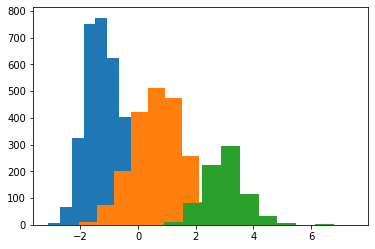

In [29]:
plt.hist(prova[0])
plt.hist(prova[1])
plt.hist(prova[2])
plt.show()

In [30]:
print(len(prova[0]))
print(len(prova[1]))
print(len(prova[2]))

3240
2068
770


## VP012

In [31]:
file_clust = r.TFile("Cluster_GSI2_cuts.root", "READ")

cluster_v1 = file_clust.Get("cluster_v1")

file_pca = r.TFile("PCA_012.root", "RECREATE")

campione_pca = cluster_v1.CopyTree("k1 >=1 && k2>= 2")
campione_pca.Write("pca")

file_pca.Close()

In [32]:
file_clust.Close()

In [33]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_012.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [34]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI2/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [35]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR2_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [36]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR012")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_012")

352

In [37]:
fit_func2 = r.TF1("fit_func2", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -3.5, 5.5)

fit_func2.SetParameters(120, -1.5, .5, 60, 0.8, .7, 20, 3.5, 0.3)

fit_func2.SetParLimits(0, 90, 400)
fit_func2.SetParLimits(3, 30, 200)
fit_func2.SetParLimits(6, 10, 35)

fit_func2.SetParLimits(8, 0.001, .9)

In [38]:
r.Math.MinimizerOptions.SetDefaultMinimizer("Minuit")
r.Math.MinimizerOptions.SetDefaultTolerance(1e-10)
r.Math.MinimizerOptions.SetDefaultMaxIterations(200)

In [39]:
pca_1.Draw("VR012>>v123s(75, -4., 7.)", "", "COLZ")

histos = r.gDirectory.Get("v123s")
histos.SetTitle("VP_{012} [k_{1}>=1 && k_{2}>=2]; VP_{012}; Entries")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(120, -1.5, .5, 60, 0.9, 0.7, 40, 3., 0.5)
r.gStyle.SetOptStat(0)

#ampiezze
fit_func.SetParLimits(0, 100, 600)
fit_func.SetParLimits(3, 20, 250)
fit_func.SetParLimits(6, 20, 150)

#punto medio
fit_func.SetParLimits(1, -1.5, 0.)
fit_func.SetParLimits(4, -0.5, 1.)
fit_func.SetParLimits(7, 2., 3.)

#deviazione_st
fit_func.SetParLimits(2, 0., 1.)
fit_func.SetParLimits(5, 0.2, 2)
fit_func.SetParLimits(8, 0.3, 1.5)

tr = -1.6

histos.Fit("fit_func", "S", "", tr, 7.)
histos.GetFunction("fit_func").SetLineColor(2)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(95)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()), "")
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()), "" )
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 4)), "")
legend.Draw("SAME")

t1 = r.TText(4, 200, brick_id)
t1.SetTextColor(1)
t1.SetTextSize(20)
t1.Draw("SAME")


c.Draw()

 FCN=37.2654 FROM MIGRAD    STATUS=CONVERGED     696 CALLS         697 TOTAL
                     EDM=4.75458e-15    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   1.1 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.31567e+02   1.65869e+01  -5.20422e-08  -2.50342e-06
   2  p1          -1.01683e+00   8.48846e-02  -4.43833e-08   5.93978e-07
   3  p2           6.98930e-01   9.81703e-02  -3.92360e-08  -5.94386e-08
   4  p3           1.57493e+02   2.29583e+01   4.77159e-08   6.16873e-07
   5  p4           6.58365e-01   1.96923e-01  -1.18578e-07   9.91054e-07
   6  p5           7.09825e-01   1.42337e-01   7.19838e-08   1.80848e-06
   7  p6           5.41368e+01   4.30114e+00  -1.72561e-08   3.85356e-07
   8  p7           2.73528e+00   1.30372e-01   7.08537e-08  -2.48537e-07
   9  p8           7.37381e-01   7.58592e-02  -1.27813e-08   1.01069e-06


In [40]:
file_name012 = '012.root'
tup_name012 = '012_c'
prova = make_classification_012_X(pca_1, fit_func, file_name012, tup_name012, 3, tr, 2, 3, 4)

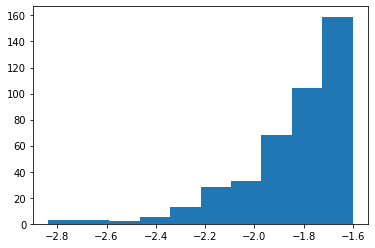

418
1
0


In [41]:
plt.hist(prova[0])
plt.show()

print(len(prova[0]))
print(len(prova[1]))
print(len(prova[2]))

## VP013

In [42]:
file_clust = r.TFile("Cluster_GSI2_cuts.root", "READ")

cluster_v1 = file_clust.Get("cluster_v1")

file_pca = r.TFile("PCA_013.root", "RECREATE")

campione_pca = cluster_v1.CopyTree("k3>=2")
campione_pca.Write("pca")

file_pca.Close()

In [43]:
file_clust.Close()

In [76]:
principal = r.TPrincipal(3, "ND")

file_pca = r.TFile("PCA_013.root", "READ")
info_pca = file_pca.Get("pca")

for track in info_pca:
    vr0, vr1, vr2 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr0
    vrs[1] = vr1
    vrs[2] = vr2
    principal.AddRow(vrs)
    
principal.MakePrincipals()
principal.MakeCode()

Writing on file "pca.C" ... done


In [77]:
r.gInterpreter.ProcessLine('.L pca.C+')

0

Info in <ACLiC>: modified script has already been compiled and loaded
Info in <ACLiC>: it will be regenerated and reloaded!
Info in <TUnixSystem::ACLiC>: creating shared library /home/baronunix/Scripts/GSI2/pca_C.so
Warning in cling::IncrementalParser::CheckABICompatibility():
  Possible C++ standard library mismatch, compiled with __GLIBCXX__ '20220324'
  Extraction of runtime standard library version was: '20220421'


In [78]:
r.gSystem.Load("pca_C.so")
vr123s = []
for track in info_pca:
    vr2, vr3, vr0 = track.VR0_av, track.VR1_av, track.VR3_av
    vrs = np.zeros(3)
    vrs[0] = vr2
    vrs[1] = vr3
    vrs[2] = vr0
    princ = np.zeros(3)
    principal.X2P(vrs, princ)
    vr123s.append(princ)

vr123 = []
for i in vr123s:
    vr123.append(i[0])
    
file_pca.Close()

In [79]:
file_pca_2 = r.TFile("PCA3.root", "RECREATE")

pca_1 = r.TNtuple("pca_2", "", "VR013")

for i in range(len(vr123)):
    pca_1.Fill(vr123[i])
pca_1.Write("pca_013")

350

In [80]:
pca_1.Draw("VR013>>v123s(75, -4., 7.)", "", "COLZ")

histos = r.gDirectory.Get("v123s")
histos.SetTitle("VR013; VR013; Conteggi")
fit_func = r.TF1("fit_func", "[0]*TMath::Gaus(x, [1], [2]) + [3]*TMath::Gaus(x, [4], [5]) + [6]*TMath::Gaus(x, [7], [8])", -4, 7)
fit_func.SetParameters(120, -1.5, .5, 60, 0.9, 0.7, 40, 3., 0.5)

#ampiezze
fit_func.SetParLimits(0, 300, 600)
fit_func.SetParLimits(3, 20, 250)
fit_func.SetParLimits(6, 20, 150)

#punto medio
fit_func.SetParLimits(1, -1.5, 0.)
fit_func.SetParLimits(4, -0.5, 1.)
fit_func.SetParLimits(7, 2., 3.5)

#deviazione_st
fit_func.SetParLimits(2, 0., 1.)
fit_func.SetParLimits(5, 0.2, 2)
fit_func.SetParLimits(8, 0.3, 1.5)

tr = -1.36

histos.Fit("fit_func", "S", "", tr, 7.)
histos.GetFunction("fit_func").SetLineColor(2)

c = r.TCanvas()
histos.Draw("PE")

params = fit_func.GetParameters()

comp1 = r.TF1("comp1", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp1.SetParameters(params[0], params[1], params[2])
comp1.SetLineColor(4)
comp1.Draw("SAME")

comp2 = r.TF1("comp2", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp2.SetParameters(params[3], params[4], params[5])
comp2.SetLineColor(6)
comp2.Draw("SAME")

comp3 = r.TF1("comp3", "[0]*TMath::Gaus(x, [1], [2])", -3, 6.)
comp3.SetParameters(params[6], params[7], params[8])
comp3.SetLineColor(8)
comp3.Draw("SAME")

legend = r.TLegend(0.6,0.65,0.88,0.85)
legend.SetTextFont(0)
legend.SetTextSize(0.04)
#legend.AddEntry(histo, "VR123", "lpe")
legend.AddEntry(fit_func, "Fit")
legend.AddEntry(comp1, "Z = 2")
legend.AddEntry(comp2, "Z = 3")
legend.AddEntry(comp3, "Z > 3")
legend.AddEntry("testo", "Entries = " + str(histos.GetEntries()))
legend.AddEntry("chi2 / NDF", "#chi^{2} / NDF = " + str(round(fit_func.GetChisquare(), 2)) + " / " + str(fit_func.GetNDF()) )
legend.AddEntry("prob", "Prob = " + str(round(fit_func.GetProb(), 10)))
legend.Draw("SAME")

c.Draw()

 FCN=54.1045 FROM MIGRAD    STATUS=CONVERGED     755 CALLS         756 TOTAL
                     EDM=1.44181e-13    STRATEGY= 1  ERROR MATRIX UNCERTAINTY   1.3 per cent
  EXT PARAMETER                                   STEP         FIRST   
  NO.   NAME      VALUE            ERROR          SIZE      DERIVATIVE 
   1  p0           3.00000e+02   1.65330e+01  -0.00000e+00** at limit **
   2  p1          -1.09951e+00   6.08691e-02  -0.00000e+00   1.01928e-05
   3  p2           5.93042e-01   9.66582e-02  -0.00000e+00   1.14074e-05
   4  p3           1.56694e+02   1.72682e+01  -0.00000e+00   1.42595e-05
   5  p4           2.89546e-01   1.12281e-01  -0.00000e+00   2.45424e-06
   6  p5           7.56930e-01   5.35358e-02  -0.00000e+00   7.48071e-06
   7  p6           4.30686e+01   3.61866e+00   0.00000e+00   4.73740e-06
   8  p7           2.50885e+00   2.11341e-01  -0.00000e+00   3.36630e-06
   9  p8           9.65395e-01   1.10157e-01   0.00000e+00   6.96390e-06


Info in <ROOT::Math::ParameterSettings>: lower/upper bounds outside current parameter value. The value will be set to (low+up)/2 


In [81]:
def make_classification_013_X(PCA_tup, fit_func, file_name, tupname, N_gaus=4, tr=-1.5, Z0=2, Z1=3, Z2=4): 
    
    params = fit_func.GetParameters()
    file_pca2 = r.TFile(file_name, "RECREATE")
    low_value, high_value = 0., 0.
    
    pca_2 = r.TNtuple(tupname, "", "VR012:Z_013")
    Z_c = 0.
    cn_s = []
    for i in range(N_gaus+1):
        cn_s.append([])
        
    for track in PCA_tup:
        PCA_value = track.VR013
        
        if (PCA_value>tr):
            cn_s[-1].append(PCA_value)
            Z_c = 11
            pca_2.Fill(PCA_value, Z_c)
            continue
        
        random_number = np.random.uniform(0,1)
        probs = []
        for i in range(N_gaus):
            probs.append(g_func(PCA_value, params[0+int(3*i)], params[1+int(3*i)], params[2+int(3*i)])/fit_func.Eval(PCA_value) )
        o_ps = sorted(probs)
        indexes = []
        for p in probs:
            indexes.append(o_ps.index(p))
        
        if (random_number <= o_ps[0]):
            check = True
            pos = 0
            for j1 in range(len(indexes)):
                if (indexes[j1] == 0): 
                    pos = j1
            for j2 in range(len(indexes)):
                if (j2 != pos and indexes[j2] == 0):
                    check = False
            if (check):
                cn_s[pos].append(PCA_value)
                if (pos == 0):
                    Z_c = Z0
                elif (pos == 1):
                    Z_c = Z1
                elif (pos == 2):
                    Z_c = Z2
                
                
        for k in range(N_gaus-1):
            
            if (k == 0):
                low_value = o_ps[0]
            elif (k == 1):
                low_value = o_ps[0] + o_ps[k]
            elif (k == 2):
                low_value = high_value
            high_value = low_value + o_ps[k+1]
        
            if (k < N_gaus-2):
                if (random_number > low_value and random_number <= high_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                    	    Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
                
            elif (k == N_gaus-2):  #funziona per N_gaus = 4
                if (random_number > low_value):
                    check = True
                    pos = 0
                    for j1 in range(len(indexes)):
                        if (indexes[j1] == k+1): 
                            pos = j1
                    for j2 in range(len(indexes)):
                        if (j2 != pos and indexes[j2] == k+1):
                            check = False
                    if (check):
                        cn_s[pos].append(PCA_value)
                        if (pos == 0):
                            Z_c = Z0
                        elif (pos == 1):
                            Z_c = Z1
                        elif (pos == 2):
                            Z_c = Z2
    
        
        pca_2.Fill(PCA_value, Z_c)     
    pca_2.Write(tupname)
    file_pca2.Close()
    return cn_s

In [82]:
file_name013 = '013.root'
tup_name013 = '013_c'
prova2 = make_classification_013_X(pca_1, fit_func, file_name013, tup_name013, 3, tr, 2, 3, 4)

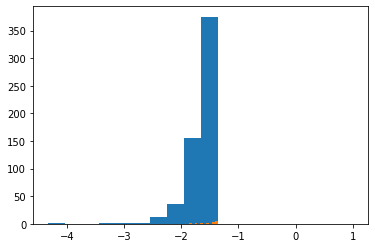

In [84]:
plt.hist(prova2[0])
plt.hist(prova2[1])
plt.hist(prova2[2])
plt.show()

In [85]:
print(len(prova2[0]))
print(len(prova2[1]))
print(len(prova2[2]))

585
15
0


## VP01?

In [51]:
'''
file_pca = r.TFile("PCA_01.root", "RECREATE")

frag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"

cond = " && k1>0 && k2<2 && k3<2"
new_cut2 = frag_cut + cond

campione_pca = tracks_2.CopyTree(new_cut2)
campione_pca.Write("pca")

file_pca.Close()
'''

'\nfile_pca = r.TFile("PCA_01.root", "RECREATE")\n\nfrag_cut = "VR0_av >= " + str(a2) + "*(1 + TMath::Exp(" + str(b2) + " *tan*tan))"\n\ncond = " && k1>0 && k2<2 && k3<2"\nnew_cut2 = frag_cut + cond\n\ncampione_pca = tracks_2.CopyTree(new_cut2)\ncampione_pca.Write("pca")\n\nfile_pca.Close()\n'

## Scrittura Output

In [86]:
file = r.TFile(track_name, "READ")
tracks = file.Get("tracks")

In [87]:
file_name01 = '01.root'
tup_name01 = '01_c'
file_name012 = '012.root'
tup_name012 = '012_c'
file_name123 = '123.root'
tup_name123 = 'tup'
file_name013 = '013.root'
tup_name013 = '013_c'

In [88]:
## Definizione tree in uscita

file_out = r.TFile(outname, "RECREATE")

Z_rec = np.zeros(1, dtype = np.intc)

output_tree = tracks.CloneTree(0)

#tracks.SetBranchAddress("n0", Z_rec)
output_tree.Branch("Z", Z_rec, "Z/I")
tracks.BuildIndex("trid")

66551

In [89]:
## tree con variabili di volume

nseg0 = np.zeros(1, dtype = np.intc)
nseg1 = np.zeros(1, dtype = np.intc)
nseg2 = np.zeros(1, dtype = np.intc)
nseg3 = np.zeros(1, dtype = np.intc)

volume0 = np.zeros(1, dtype = np.double)
volume1 = np.zeros(1, dtype = np.double)
volume2 = np.zeros(1, dtype = np.double)
volume3 = np.zeros(1, dtype = np.double)


output_tree2 = tracks.CloneTree(0)
output_tree2.Branch("VR0_av", volume0, "VR0_av/D")
output_tree2.Branch("VR1_av", volume1, "VR1_av/D")
output_tree2.Branch("VR2_av", volume2, "VR2_av/D")
output_tree2.Branch("VR3_av", volume3, "VR3_av/D")

output_tree2.Branch("k0", nseg0, "k0/I")
output_tree2.Branch("k1", nseg1, "k1/I")
output_tree2.Branch("k2", nseg2, "k2/I")
output_tree2.Branch("k3", nseg3, "k3/I")

output_tree2.Branch("Z", Z_rec, "Z/I")


In [90]:
for i in range(tracks.GetEntries()):
    tracks.GetEntry(i)
    k0, k1, k2, k3 = 0, 0, 0, 0
    VR0av, VR1av, VR2av, VR3av = 0, 0, 0, 0
    vr0, vr1, vr2, vr3 = 0, 0, 0, 0
    for s in tracks.s:
        if((s.Plate()-31)%4 - 0 == 0):
            k0+=1
            vr0 += s.Volume()
        if((s.Plate()-31)%4 - 1 == 0):
            k1+=1
            vr1 += s.Volume()   
        if((s.Plate()-31)%4 - 2 == 0):
            k2+=1
            vr2 += s.Volume()
        if((s.Plate()-31)%4 - 3 == 0):
            k3+=1
            vr3 += s.Volume()      
    if(k0!=0):
            VR0av = vr0/k0
    if(k1!=0):
            VR1av = vr1/k1
    if(k2!=0):
            VR2av = vr2/k2
    if(k3!=0):
            VR3av = vr3/k3
            
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = k0, k1, k2, k3
    volume0[0], volume1[0], volume2[0], volume3[0] = VR0av, VR1av, VR2av, VR3av
    
    if (k0<k0_min or VR0av>=25000):
        Z_rec[0] = -5
        
        output_tree.Fill()
        output_tree2.Fill()

In [91]:
output_tree.GetEntries()

1996

In [92]:
count = 0
g1, g2, g3, g4, g5, g6, g7 = 0, 0, 0, 0, 0, 0, 0
for i in range(tracks_2.GetEntries()):
    tracks_2.GetEntry(i)
    tracks.GetEntry(tracks_2.trid)
    frag_cut = (tracks_2.VR0_av >= a2*(1 + np.exp(b2 * tracks_2.tan*tracks_2.tan)))
    cond1 = (tracks_2.k2 <=1 and tracks_2.k3<=1)
    cond11 = tracks_2.k1<=1
    cond2 = tracks_2.VR1_av>0
    cond3 = tracks_2.VR1_av>6000
    cond0 = tracks_2.VR1_av == 0
    cond4 = tracks_2.k2 == 0

    cond_vp123 = (tracks_2.k1>0 and tracks_2.k2>0 and tracks_2.k3>1) or (tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3>0)
    cond_vp012 = tracks_2.k1>0 and tracks_2.k2>1 and tracks_2.k3<1
    cond_vp013 = tracks_2.k1>0 and tracks_2.k2<1 and tracks_2.k3>1
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if ((i%10000)==0):
        print("Carica Assegnata a " + str(round(count,2)) + " tracce, su " + str(tracks_2.GetEntries()))

    if (tracks_2.k0<k0_min or tracks_2.VR0_av>=25000):
        continue
    if (frag_cut and cond1 and cond11):
        Z_rec[0] = 1
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g1 = g1 + 1
        continue
    if ((not frag_cut) and cond1 and cond11):
        Z_rec[0] = -1
        #print("Z=" +str(Z_rec))
        output_tree.Fill()
        output_tree2.Fill()
        count = count + 1
        g4 = g4 + 1
        continue
    
    if (tracks_2.k1>=2 or tracks_2.k2>=2 or tracks_2.k3>=2):

        if ( frag_cut and (not cond11) and cond1):
            g2 = g2 + 1 
            count = count + 1
            if (tracks_2.VR1_av > c0):
                Z_rec[0] = 2
                #print("Z= "+str(Z_rec))
                output_tree.Fill()
                output_tree2.Fill()
                continue
            else:
                Z_rec[0] = 1
                #print("Z= "+str(Z_rec))
                output_tree.Fill()
                output_tree2.Fill()
                continue

        if (cond_vp123):
            g5 = g5 + 1
            continue
        elif (cond_vp012):
            g6 = g6 + 1
            continue
        elif (cond_vp013):
            g7 = g7 +1
            continue
        else:
            Z_rec[0] = 10
            output_tree.Fill()
            output_tree2.Fill()
            continue
    if (count == 0):
        print("Errore")
    #print("count= " + str(count))
print(g1, g2, g3, g4, g5 ,g6, g7)   

Carica Assegnata a 0 tracce, su 64555
Carica Assegnata a 8497 tracce, su 64555
Carica Assegnata a 16235 tracce, su 64555
Carica Assegnata a 24373 tracce, su 64555
Carica Assegnata a 34068 tracce, su 64555
Carica Assegnata a 43687 tracce, su 64555
Carica Assegnata a 53508 tracce, su 64555
16648 3058 0 38208 6078 432 75


In [93]:
print(output_tree.GetEntries())
print(g1+g2+g3+g4+g5+g6+g7)

59966
64499


#### Classificazione 123

In [94]:
file_pca123 = r.TFile(file_name123, "READ")
pca_3 = file_pca123.Get(tup_name123)

file_info_pca123 = r.TFile("PCA_123.root", "READ")
info_pca123 = file_info_pca123.Get("pca")

pca_3.AddFriend(info_pca123)
tracks_2.BuildIndex("trid", "npl")
count3 = 0
count_z3, count_z2, count_z4 = 0, 0,0

for track_123 in pca_3:
    
    trid_to_assign, npl_to_assign = track_123.trid, track_123.npl
    tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
    tracks.GetEntry(tracks_2.trid)
    
    check0 = (track_123.k1>0 and track_123.k2>0 and track_123.k3>1) or (track_123.k1>0 and track_123.k2>1 and track_123.k3>0)
    #check0 = track_123.k2>1 and track_123.k3>1
    check1 = track_123.tan == tracks_2.tan and track_123.k0 == tracks_2.k0 and track_123.VR0_av == tracks_2.VR0_av
    check2 = track_123.k1 == tracks_2.k1 and track_123.VR1_av == tracks_2.VR1_av
    check3 = track_123.k2 == tracks_2.k2 and track_123.VR2_av == tracks_2.VR2_av
    check4 = track_123.k3 == tracks_2.k3 and track_123.VR3_av == tracks_2.VR3_av
    check5 = track_123.nseg == tracks_2.nseg and track_123.npl == tracks_2.npl
    check = check1 and check2 and check3 and check4 and check5 and check0
    
    nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
    volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
    
    if (check):
        Z_rec[0] = int(track_123.Z_c)
        if (Z_rec[0]==3):
            count_z3 += 1
        elif(Z_rec[0]==2):
            count_z2 += 1
        elif(Z_rec[0]==4):
            count_z4 += 1
        #print(Z_rec)
        output_tree.Fill()
        output_tree2.Fill()
        count3 = count3 +1
    #if (count == 0):
        #print("Error")
        #break
    
    if (count3%1000 == 0):
        print("Carica assegnata a " + str(count+count3) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca123.Close()
file_info_pca123.Close()
print("100%")
print(count3)
print(" Added " + str(count_z2) + " Z=2")
print(" Added " + str(count_z3) + " Z=3")
print(" Added " + str(count_z4) + " Z=4")

Carica assegnata a 58914 tracce, su 64555
Carica assegnata a 59914 tracce, su 64555
Carica assegnata a 60914 tracce, su 64555
Carica assegnata a 61914 tracce, su 64555
Carica assegnata a 62914 tracce, su 64555
Carica assegnata a 63914 tracce, su 64555
100%
6078
 Added 3240 Z=2
 Added 2068 Z=3
 Added 770 Z=4


### Classificazione 012

In [95]:
file_pca012 = r.TFile(file_name012, "READ")
pca_012 = file_pca012.Get(tup_name012)

file_info_pca012 = r.TFile("PCA_012.root", "READ")
info_pca012 = file_info_pca012.Get("pca")

pca_012.AddFriend(info_pca012)
#tracks_2.BuildIndex("trid", "npl")
count4 = 0
count_z3, count_z2, count_z4 = 0, 0,0

for track_012 in pca_012:
    
    countx = 0
    if (track_012.k2 > 1 and track_012.k3<1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check and track_012.VR2_av < 8000):
            Z_rec[0] = int(track_012.Z_012)
            if (Z_rec[0]==3):
                count_z3 += 1
            elif(Z_rec[0]==2):
                count_z2 += 1
            elif(Z_rec[0]==4):
                count_z4 += 1
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        elif (check and track_012.VR2_av > 8000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            countx = countx + 1
            count4 = count4 +1
        #if (count == 0):
            #print("Error")
            #break
        
        if (count4%100 == 0):
           print("Carica assegnata a " + str(count+count3+count4) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca012.Close()
file_info_pca012.Close()
print("100%")
print(count4)
print(" Added " + str(count_z2) + " Z=2")
print(" Added " + str(count_z3) + " Z=3")
print(" Added " + str(count_z4) + " Z=4")

Carica assegnata a 64092 tracce, su 64555
Carica assegnata a 64192 tracce, su 64555
Carica assegnata a 64292 tracce, su 64555
Carica assegnata a 64392 tracce, su 64555
100%
432
 Added 0 Z=2
 Added 0 Z=3
 Added 140 Z=4


In [96]:
file_pca013 = r.TFile(file_name013, "READ")
pca_013 = file_pca013.Get(tup_name013)

file_info_pca013 = r.TFile("PCA_013.root", "READ")
info_pca013 = file_info_pca013.Get("pca")

pca_013.AddFriend(info_pca013)
#tracks_2.BuildIndex("trid", "npl")
count5 = 0
count_z3, count_z2, count_z4 = 0, 0,0

for track_012 in pca_013:
    
    if (track_012.k3 > 1 and track_012.k2<1):
        trid_to_assign, npl_to_assign = track_012.trid, track_012.npl
        tracks_2.GetEntryWithIndex(trid_to_assign, npl_to_assign)
        tracks.GetEntry(tracks_2.trid)
    
        check1 = track_012.tan == tracks_2.tan and track_012.k0 == tracks_2.k0 and track_012.VR0_av == tracks_2.VR0_av
        check2 = track_012.k1 == tracks_2.k1 and track_012.VR1_av == tracks_2.VR1_av
        check3 = track_012.k2 == tracks_2.k2 and track_012.VR2_av == tracks_2.VR2_av
        check4 = track_012.k3 == tracks_2.k3 and track_012.VR3_av == tracks_2.VR3_av
        check5 = track_012.nseg == tracks_2.nseg and track_012.npl == tracks_2.npl
        check = check1 and check2 and check3 and check4 and check5
        
        nseg0[0], nseg1[0], nseg2[0], nseg3[0] = tracks_2.k0, tracks_2.k1, tracks_2.k2, tracks_2.k3
        volume0[0], volume1[0], volume2[0], volume3[0] = tracks_2.VR0_av, tracks_2.VR1_av, tracks_2.VR2_av, tracks_2.VR3_av
        
        if (check):
            Z_rec[0] = int(track_012.Z_013)
            if (Z_rec[0]==3):
                count_z3 += 1
            elif(Z_rec[0]==2):
                count_z2 += 1
            elif(Z_rec[0]==4):
                count_z4 += 1
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        elif (check and track_012.VR2_av > 10000):
            Z_rec[0] = 11
            #print(Z_rec)
            output_tree.Fill()
            output_tree2.Fill()
            count5 = count5 +1
        #if (count == 0):
            #print("Error")
            #break
        
        #if (count5%100 == 0):
           #print("Carica assegnata a " + str(count2+count+count3+count4+count5) + " tracce, su " + str(tracks_2.GetEntries()))
file_pca013.Close()
file_info_pca013.Close()
print("100%")
print(count5)
print(" Added " + str(count_z2) + " Z=2")
print(" Added " + str(count_z3) + " Z=3")
print(" Added " + str(count_z4) + " Z=4")

100%
81
 Added 25 Z=2
 Added 0 Z=3
 Added 0 Z=4


In [63]:
output_tree2.GetEntries()

66557

In [64]:
file_out.cd()
#output_tree.Write("tracks")
output_tree2.Write("tracks")   #con info su VRi_av e ki
file_out.Close()

# Plot Opzionali

In [65]:
file_out_new = r.TFile(outname, "READ")
output_tree = file_out_new.Get("tracks")

In [66]:
output_tree.Draw("s[0].Theta()>>Z5(50)", "Z > 0 && Z<10")
h4 = r.gDirectory.Get("Z5")
N2 = h4.GetEntries()
print(N2)

25949.0


In [67]:
c = r.TCanvas()

output_tree.Draw("s[0].Theta()>>Z1(100, 0, 1)", "Z == 1")
hs = r.THStack("h4s", "")
h1 = r.gDirectory.Get("Z1")
h1.SetFillColor(0)
h1.SetLineWidth(2)
h1.SetLineColor(1)
hs.Add(h1)

output_tree.Draw("s[0].Theta()>>Z2(100, 0, 1)", "Z == 2")
h2 = r.gDirectory.Get("Z2")
h2.SetFillColor(0)
h2.SetLineWidth(2)
h2.SetLineColor(4)
hs.Add(h2)

output_tree.Draw("s[0].Theta()>>Z3(100, 0, 1)", "Z == 3")
h3 = r.gDirectory.Get("Z3")
h3.SetFillColor(0)
h3.SetLineWidth(2)
h3.SetLineColor(95)
hs.Add(h3)

output_tree.Draw("s[0].Theta()>>Z4(100, 0, 1)", "Z == 4")
h4 = r.gDirectory.Get("Z4")
h4.SetFillColor(0)
h4.SetLineWidth(2)
h4.SetLineColor(8)
hs.Add(h4)


hs.SetTitle("Fragments Angular Distribution GSI2 (k_{0}>=" + str(k0_min)+"); tan(#theta); Entries")
hs.Draw("nostack")

legend = r.TLegend(0.55,0.6,0.9,0.9)
legend.SetTextFont(0)
legend.SetTextSize(0.1)

def lazy(histo, N):
    return "Entries = "+str(histo.GetEntries()) + " (" + str(round(100*histo.GetEntries()/N, 1)) + "%)}{Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+"}"

#N = 34881.0

legend.AddEntry(h1, "#splitline{Z=1, " + lazy(h1, N2))
legend.AddEntry(h2, "#splitline{Z=2, "+ lazy(h2, N2))
legend.AddEntry(h3, "#splitline{Z=3, "+ lazy(h3, N2))
legend.AddEntry(h4, "#splitline{Z=4, "+ lazy(h4, N2))

legend.Draw("SAME")
 
c.Draw()

In [75]:
PLOTS=1
if (PLOTS==1):
    ##for k0>=1
    multiplier = 1.7
    w, h = int(800*multiplier), int(600*multiplier)

    k = r.TCanvas("c", "c", w, h)
    k.SetLeftMargin(0.13)
    k.SetRightMargin(0.92)
    k.SetBottomMargin(100)
    k.SetWindowSize(w,h)

    output_tree.Draw("s[0].Theta()>>Z1(100, 0, 1)", "Z == 1")
    hs = r.THStack("h4s", "")
    h1 = r.gDirectory.Get("Z1")
    h1.SetFillColor(0)
    h1.SetLineWidth(4)
    h1.SetLineColor(1)
    hs.Add(h1)

    output_tree.Draw("s[0].Theta()>>Z2(100, 0, 1)", "Z == 2")
    h2 = r.gDirectory.Get("Z2")
    h2.SetFillColor(0)
    h2.SetLineWidth(4)
    h2.SetLineColor(4)
    hs.Add(h2)

    output_tree.Draw("s[0].Theta()>>Z3(100, 0, 1)", "Z == 3")
    h3 = r.gDirectory.Get("Z3")
    h3.SetFillColor(0)
    h3.SetLineWidth(4)
    h3.SetLineColor(95)
    hs.Add(h3)

    output_tree.Draw("s[0].Theta()>>Z4(100, 0, 1)", "Z == 4")
    h4 = r.gDirectory.Get("Z4")
    h4.SetFillColor(0)
    h4.SetLineWidth(4)
    h4.SetLineColor(8)
    hs.Add(h4)


    hs.SetTitle("; tan(#theta); Entries")
    hs.Draw("nostack")

    legend = r.TLegend(0.55,0.6,0.9,0.9)
    legend.SetTextFont(0)
    legend.SetTextSize(0.1)

    def lazy(histo, N):
        return "(Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+")"
        #return "Entries = "+str(histo.GetEntries()) + " (" + str(round(100*histo.GetEntries()/N, 1)) + "%)}{Mean: "+ str(round(histo.GetMean(), 2)) + ", RMS = "+str(round(histo.GetRMS(),2))+"}"

    #N = 34881.0

    legend.AddEntry(h1, "Z=1 " + lazy(h1, N2))
    legend.AddEntry(h2, "Z=2 "+ lazy(h2, N2))
    legend.AddEntry(h3, "Z=3 "+ lazy(h3, N2))
    legend.AddEntry(h4, "Z=4 "+ lazy(h4, N2))

    legend.Draw("SAME")
    
    t1.Draw("SAME")
    k.Draw()


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
